In [2]:
# Importing the required libraries
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import seaborn as sns
sns.set(style="whitegrid")

In [10]:
df = pd.read_csv('KC_6H_2001-2025_Final.csv')
df.head()

,msl,sst,u10,v10,ws,t2m,rh,tp,latitude,longitude,year
0,101088.562500,28.492340,2.642392,-1.809207,3.400581,26.153758,83.387161,0.511169,12.0,72.75,2001
1,101087.437500,28.472809,2.505185,-0.305300,2.694869,26.212026,82.330621,0.605583,12.0,73.00,2001
2,101089.270833,28.431793,2.257952,1.139036,2.614121,26.150177,82.778590,0.526428,12.0,73.25,2001
3,101091.937500,28.372223,2.131650,1.887733,2.862722,26.092560,83.661308,0.247955,12.0,73.50,2001
4,101093.229167,28.307770,2.167458,2.245155,3.129958,26.331167,81.227767,0.050068,12.0,73.75,2001


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14025216 entries, 0 to 14025215
Data columns (total 11 columns):
 #   Column     Dtype  
---  ------     -----  
 0   msl        float64
 1   sst        float64
 2   u10        float64
 3   v10        float64
 4   ws         float64
 5   t2m        float64
 6   rh         float64
 7   tp         float64
 8   latitude   float64
 9   longitude  float64
 10  year       int64  
dtypes: float64(10), int64(1)
memory usage: 1.1 GB


In [12]:
df['latitude'].unique(), df['longitude'].unique()

(array([12.  , 12.25, 12.5 , 12.75, 13.  , 13.25, 13.5 , 13.75, 14.  ,
        14.25, 14.5 , 14.75, 15.  , 15.25, 15.5 , 15.75, 16.  , 16.25,
        16.5 , 16.75, 17.  , 17.25, 17.5 , 17.75, 18.  , 18.25, 18.5 ,
        18.75, 19.  , 19.25, 19.5 , 19.75]),
 array([72.75, 73.  , 73.25, 73.5 , 73.75, 74.  , 74.25, 74.5 , 74.75,
        75.  , 75.25, 75.5 ]))

In [13]:
df.describe().round(3)

,msl,sst,u10,v10,ws,t2m,rh,tp,latitude,longitude,year
count,1.402522e+07,1.402522e+07,1.402522e+07,1.402522e+07,1.402522e+07,1.402522e+07,1.402522e+07,1.402522e+07,1.402522e+07,1.402522e+07,1.402522e+07
mean,1.009891e+05,2.774600e+01,1.669000e+00,-5.490000e-01,3.556000e+00,2.636000e+01,7.229400e+01,1.257000e+00,1.587500e+01,7.412500e+01,2.013001e+03
std,3.016730e+02,1.351000e+00,2.929000e+00,2.169000e+00,2.054000e+00,3.449000e+00,1.824300e+01,3.580000e+00,2.308000e+00,8.630000e-01,7.211000e+00
min,9.803890e+04,2.287600e+01,-1.990500e+01,-1.951700e+01,6.400000e-02,6.730000e+00,6.652000e+00,0.000000e+00,1.200000e+01,7.275000e+01,2.001000e+03
25%,1.007920e+05,2.677400e+01,-4.280000e-01,-1.669000e+00,2.027000e+00,2.444100e+01,6.396800e+01,0.000000e+00,1.393800e+01,7.343800e+01,2.007000e+03
50%,1.009912e+05,2.790500e+01,1.625000e+00,-3.690000e-01,3.113000e+00,2.670000e+01,7.705500e+01,3.000000e-03,1.587500e+01,7.412500e+01,2.013000e+03
75%,1.011922e+05,2.865200e+01,3.475000e+00,7.400000e-01,4.671000e+00,2.818300e+01,8.592400e+01,7.640000e-01,1.781200e+01,7.481200e+01,2.019000e+03
max,1.021954e+05,3.212700e+01,2.297300e+01,2.229900e+01,2.465700e+01,4.285800e+01,1.000060e+02,2.286800e+02,1.975000e+01,7.550000e+01,2.025000e+03


In [14]:
df1 = df.drop(columns=['latitude', 'longitude', 'year'])
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 14025216 entries, 0 to 14025215
Data columns (total 8 columns):
 #   Column  Dtype  
---  ------  -----  
 0   msl     float64
 1   sst     float64
 2   u10     float64
 3   v10     float64
 4   ws      float64
 5   t2m     float64
 6   rh      float64
 7   tp      float64
dtypes: float64(8)
memory usage: 856.0 MB


## Boxplots for Outlier Analysis

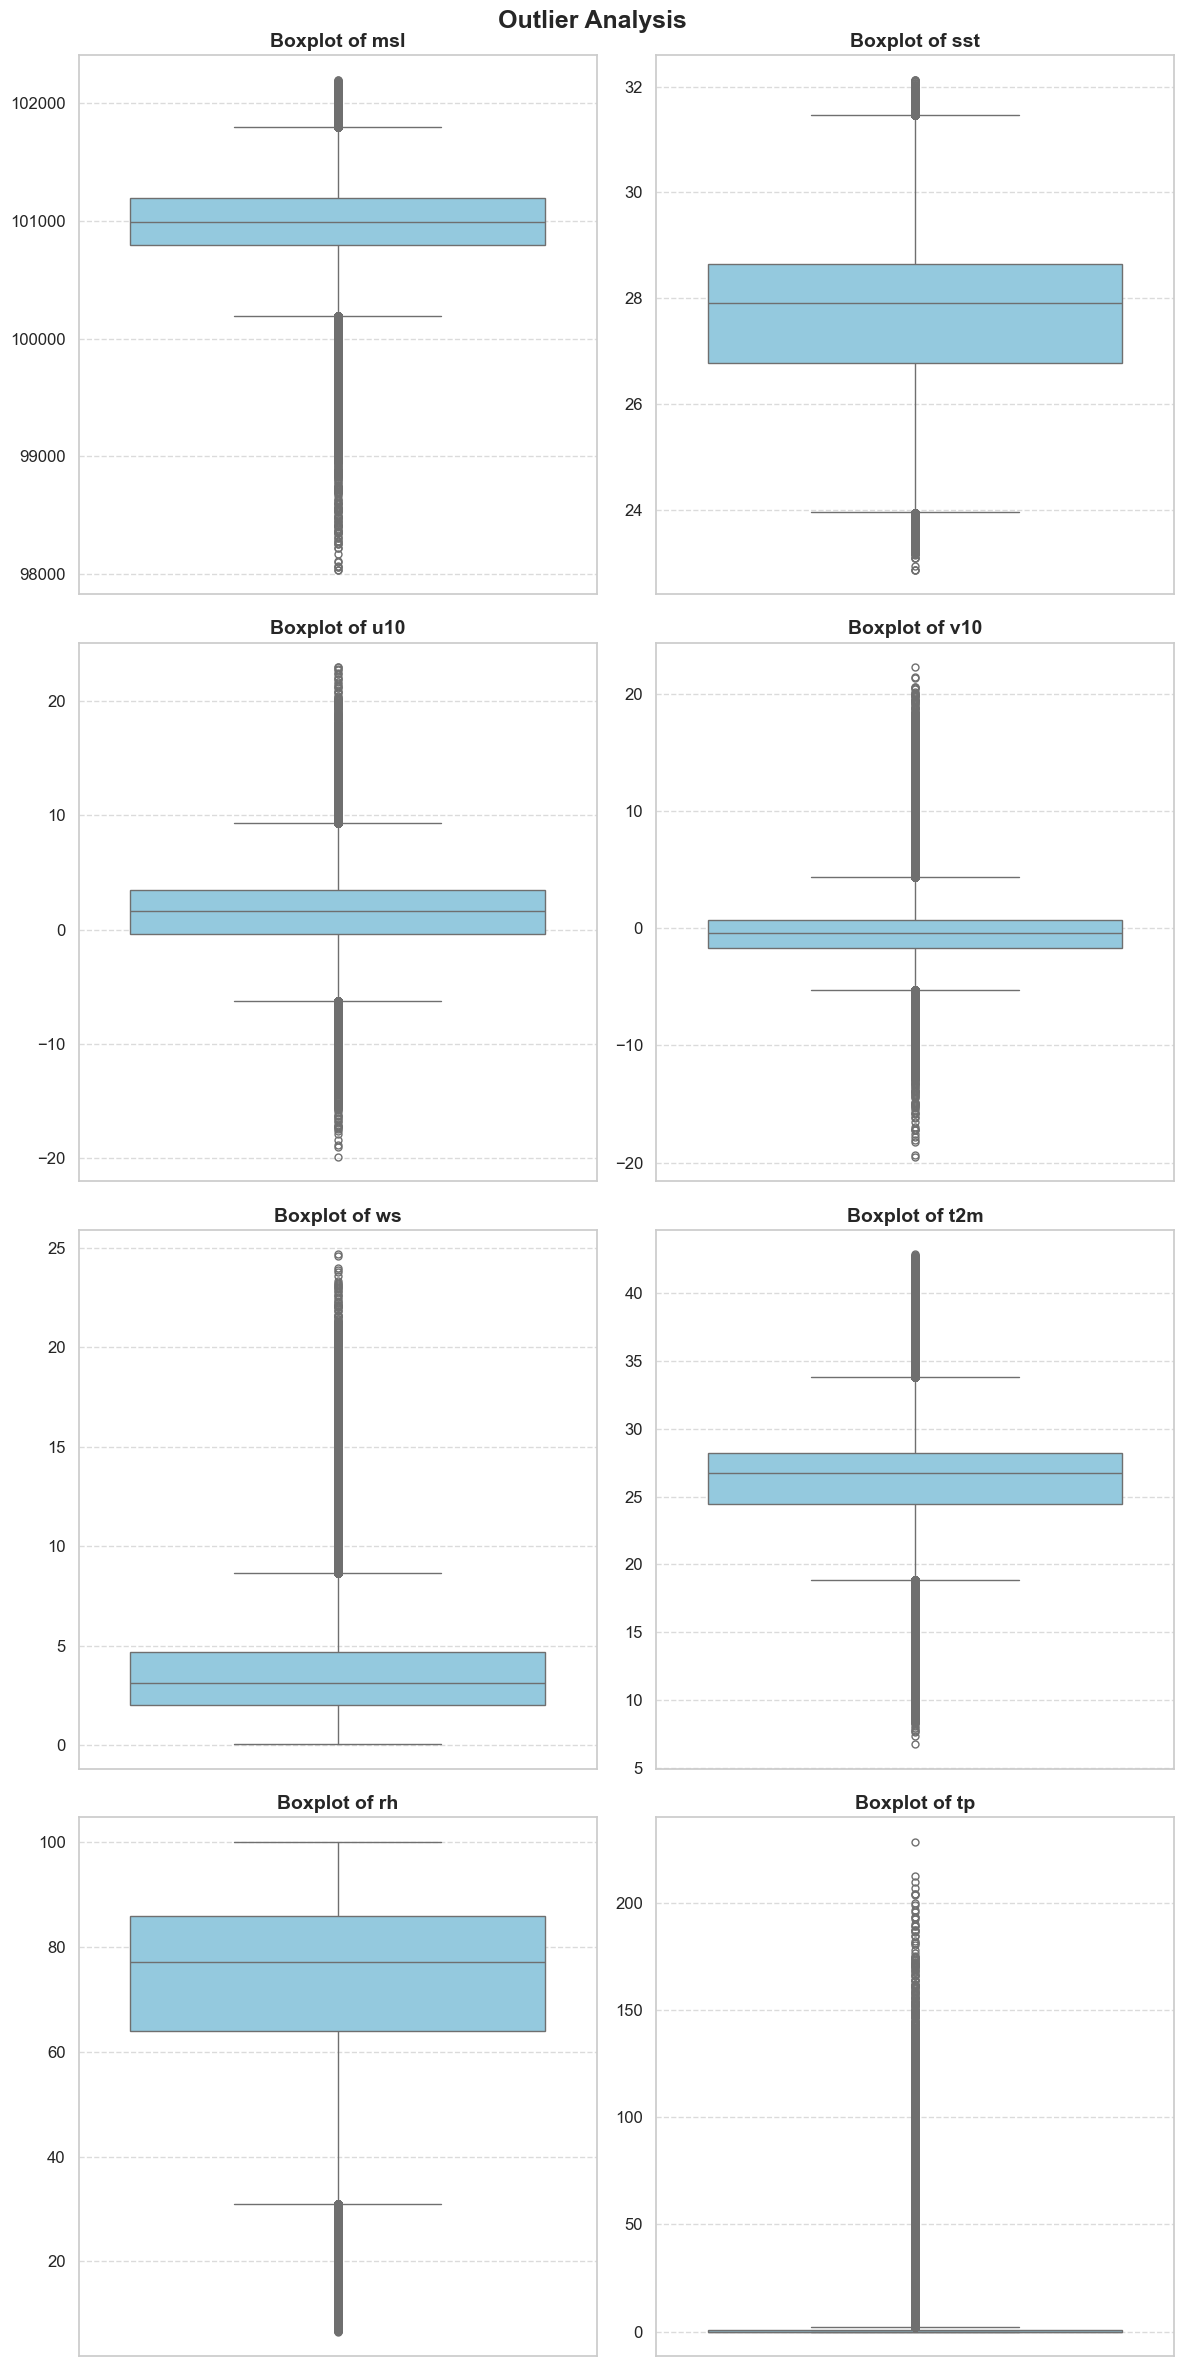

In [15]:
cols_to_plot = df1.columns
num_plots = len(cols_to_plot)
num_cols = 2
num_rows = math.ceil(num_plots / num_cols)

plt.figure(figsize=(12, 6 * num_rows))

for i, col in enumerate(cols_to_plot):
    plt.subplot(num_rows, num_cols, i + 1)
    
    sns.boxplot(y=df1[col], color='skyblue', fliersize=5)
    
    plt.title(f'Boxplot of {col}', fontsize=14, weight='bold')
    plt.ylabel('')
    plt.yticks(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Outlier Analysis', fontsize=18, y=0.985, weight='bold')
plt.tight_layout()
plt.show()

## Correlation Heatmap

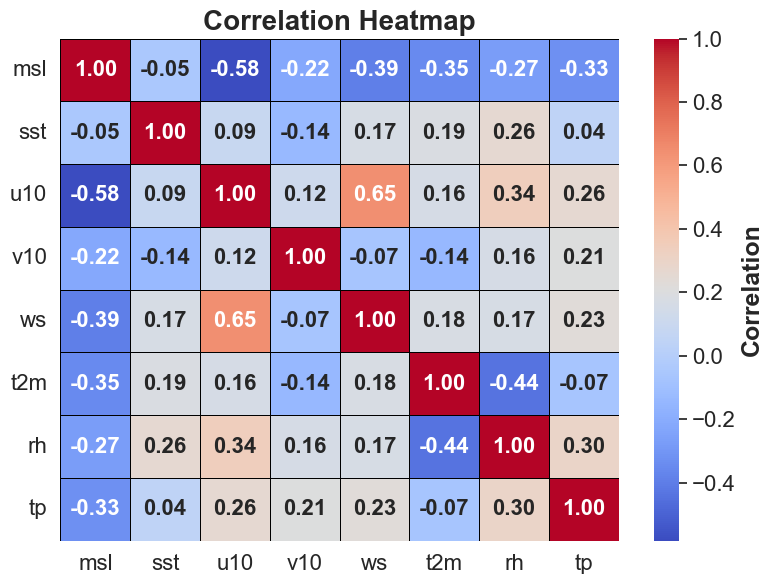

In [16]:
plt.figure(figsize=(8, 6))
corr = df1.corr()

ax = sns.heatmap(
    corr, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    linewidths=0.5, 
    linecolor='black',
    annot_kws={"size": 16, "weight": 'bold'}  
)

cbar = ax.collections[0].colorbar
cbar.set_label('Correlation', fontsize=18, weight='bold') # type: ignore
cbar.ax.tick_params(labelsize=16)  # type: ignore

plt.title('Correlation Heatmap', fontsize=20, weight='bold')
plt.xticks(fontsize=16, rotation=0)
plt.yticks(fontsize=16, rotation=0)
plt.tight_layout()

# plt.savefig('Heatmap.pdf', bbox_inches='tight')
plt.show()

## Distribution Plots for Some Features

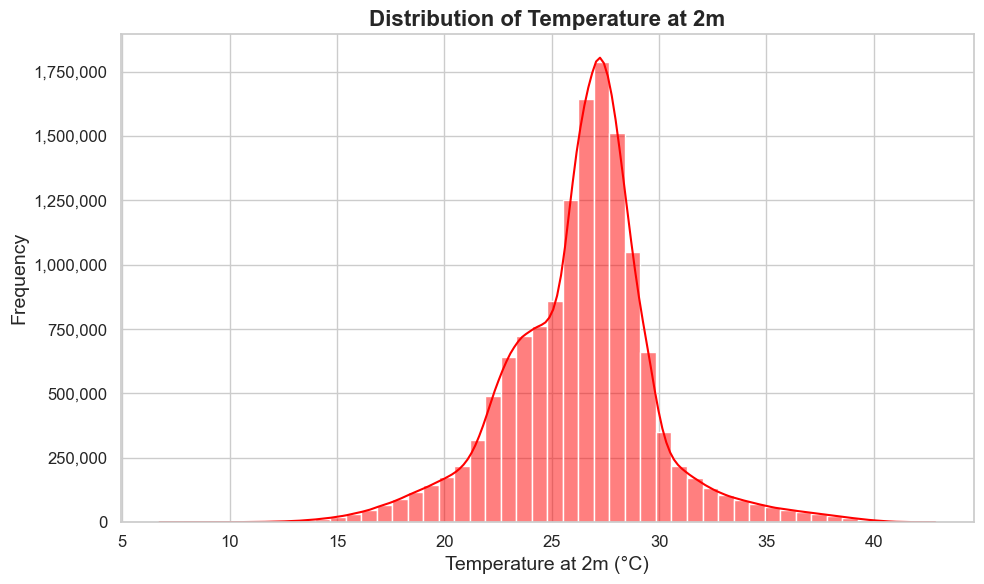

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df1['t2m'], bins=50, kde=True, color='red') # type: ignore
plt.title('Distribution of Temperature at 2m', fontsize=16, weight='bold')
plt.xlabel('Temperature at 2m (°C)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()

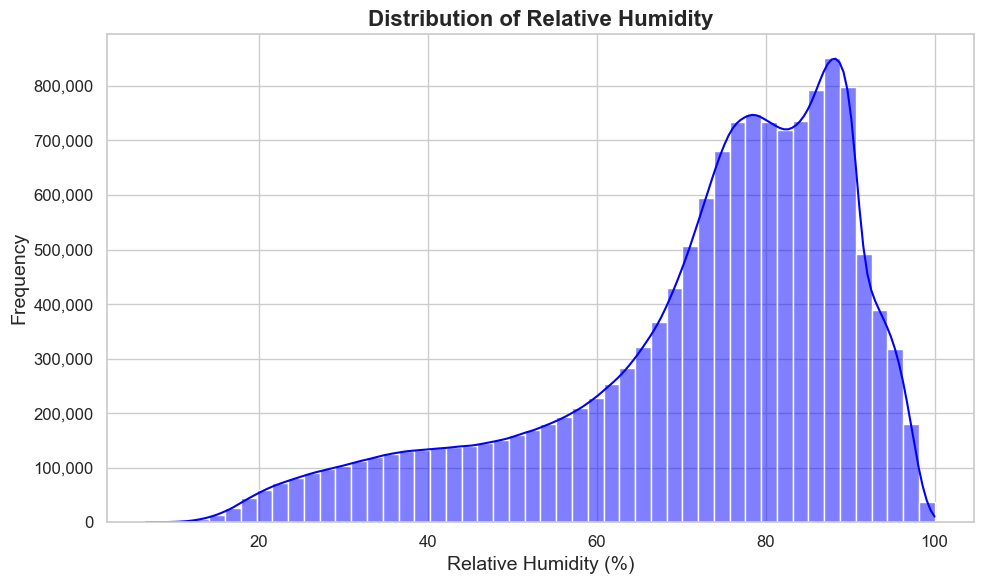

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df1['rh'], bins=50, kde=True, color='blue') # type: ignore
plt.title('Distribution of Relative Humidity', fontsize=16, weight='bold')
plt.xlabel('Relative Humidity (%)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()

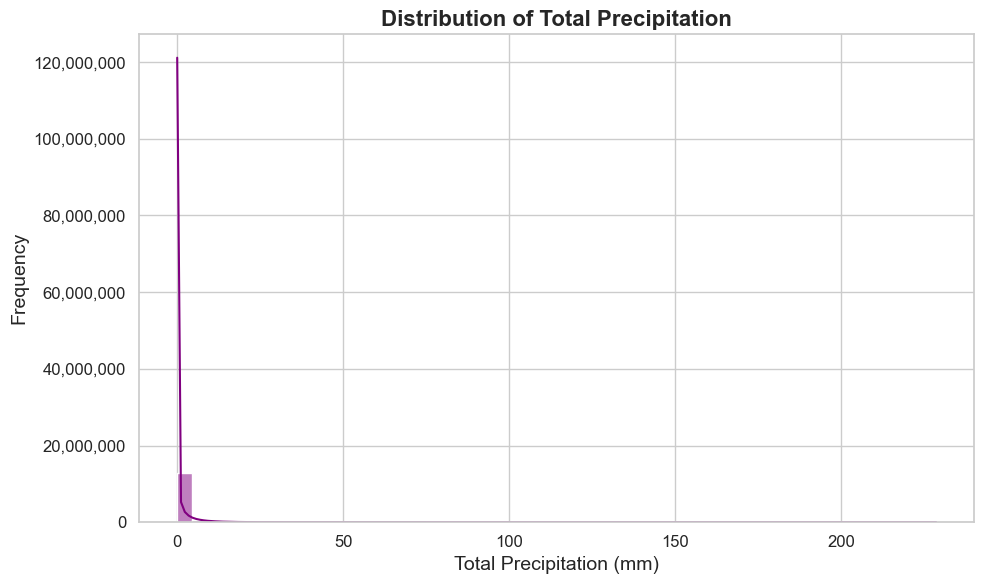

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(df1['tp'], bins=50, kde=True, color='purple') # type: ignore
plt.title('Distribution of Total Precipitation', fontsize=16, weight='bold')
plt.xlabel('Total Precipitation (mm)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()

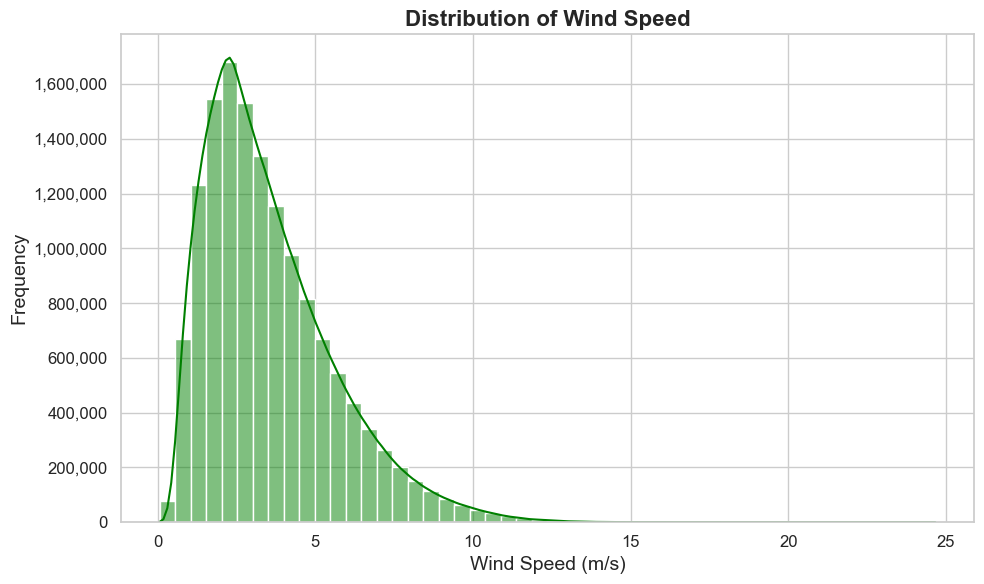

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(df1['ws'], bins=50, kde=True, color='green') # type: ignore
plt.title('Distribution of Wind Speed', fontsize=16, weight='bold')
plt.xlabel('Wind Speed (m/s)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()

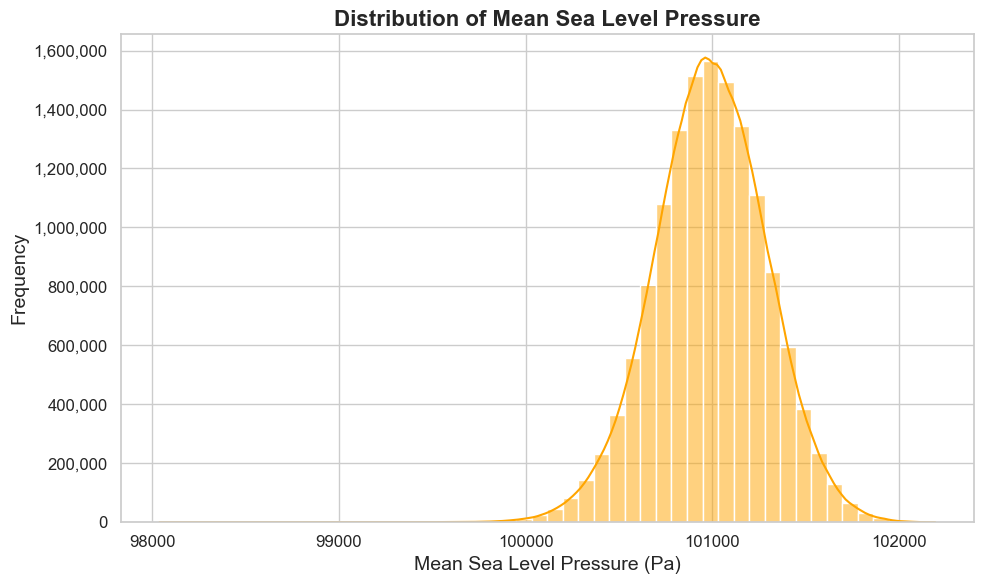

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(df1['msl'], bins=50, kde=True, color='orange') # type: ignore
plt.title('Distribution of Mean Sea Level Pressure', fontsize=16, weight='bold')
plt.xlabel('Mean Sea Level Pressure (Pa)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()

## Line Plots for Important Features

In [22]:
df2 = df.copy()

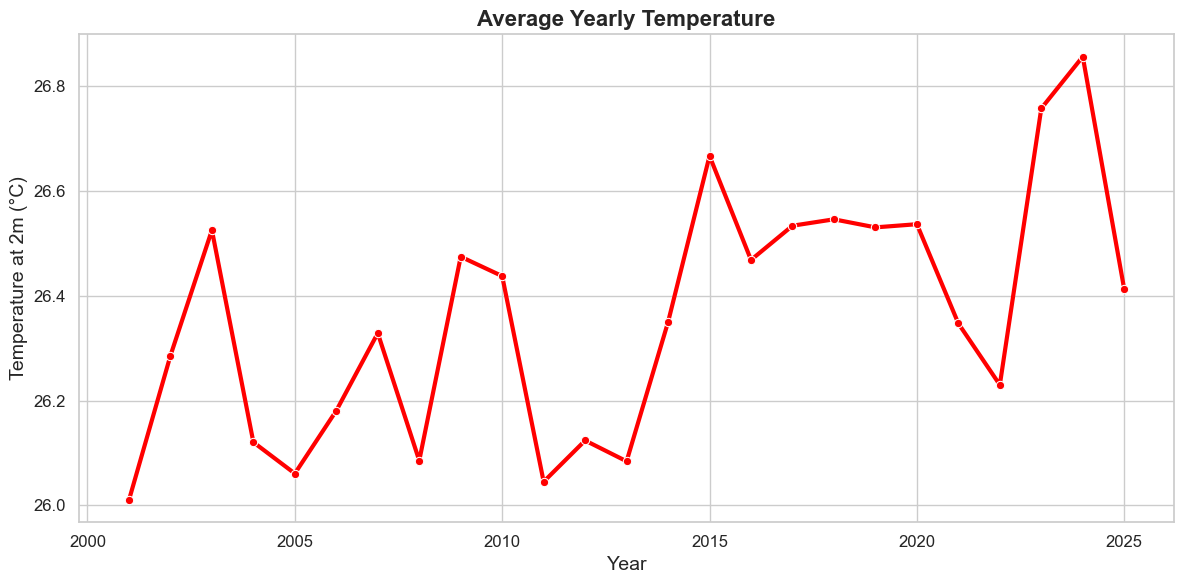

In [30]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df2, x='year', y='t2m', marker='o', linewidth=3, color='red', errorbar=None) 
plt.title('Average Yearly Temperature', fontsize=16, weight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Temperature at 2m (°C)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

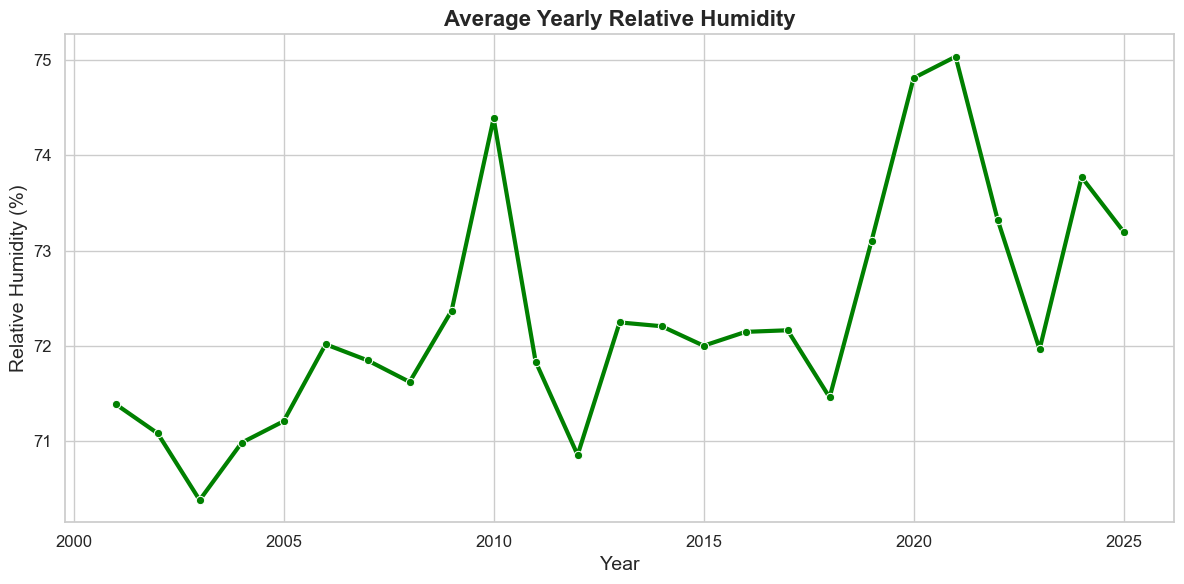

In [29]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df2, x='year', y='rh', marker='o', linewidth=3, color='green', errorbar=None) 
plt.title('Average Yearly Relative Humidity', fontsize=16, weight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Relative Humidity (%)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

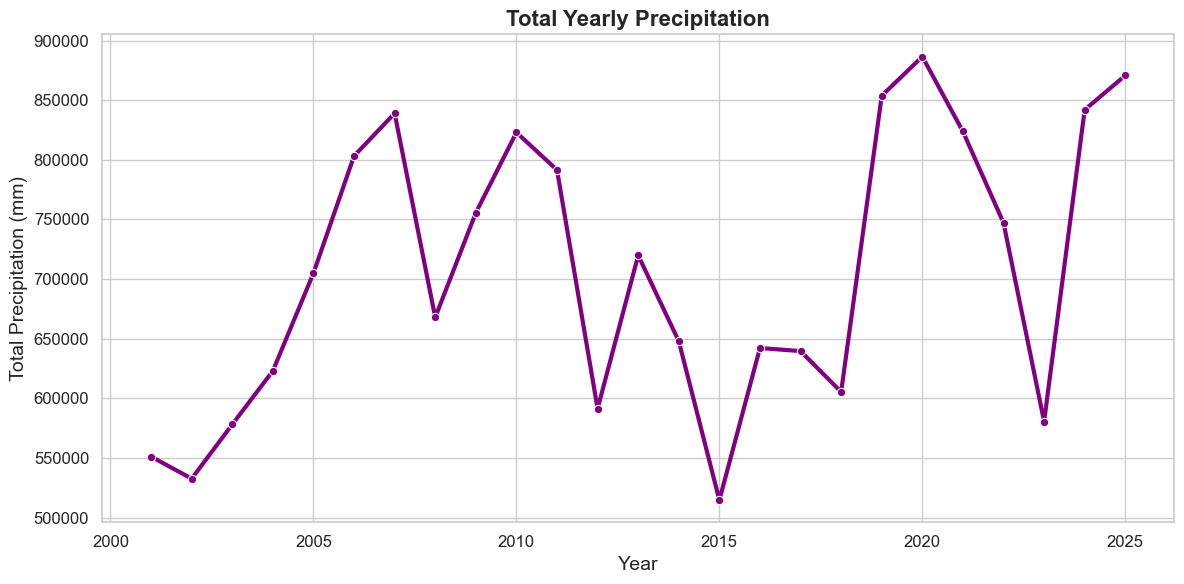

In [33]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df2, x='year', y='tp', estimator='sum', errorbar=None, marker='o', linewidth=3, color='purple') 
plt.title('Total Yearly Precipitation', fontsize=16, weight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Total Precipitation (mm)', fontsize=14) 
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

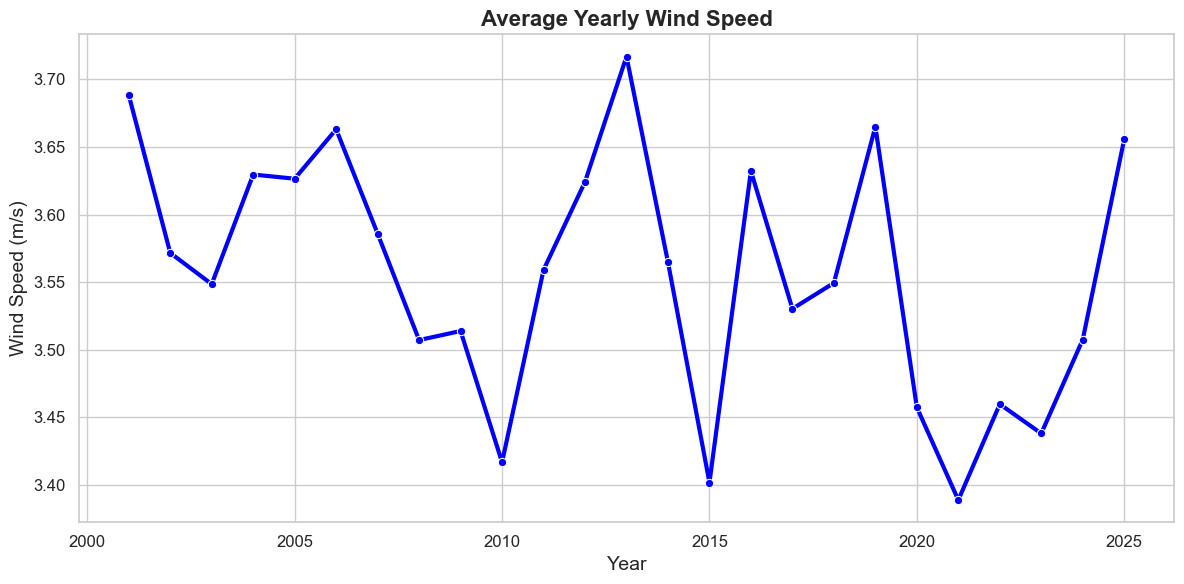

In [34]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df2, x='year', y='ws', marker='o', linewidth=3, color='blue', errorbar=None) 
plt.title('Average Yearly Wind Speed', fontsize=16, weight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Wind Speed (m/s)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

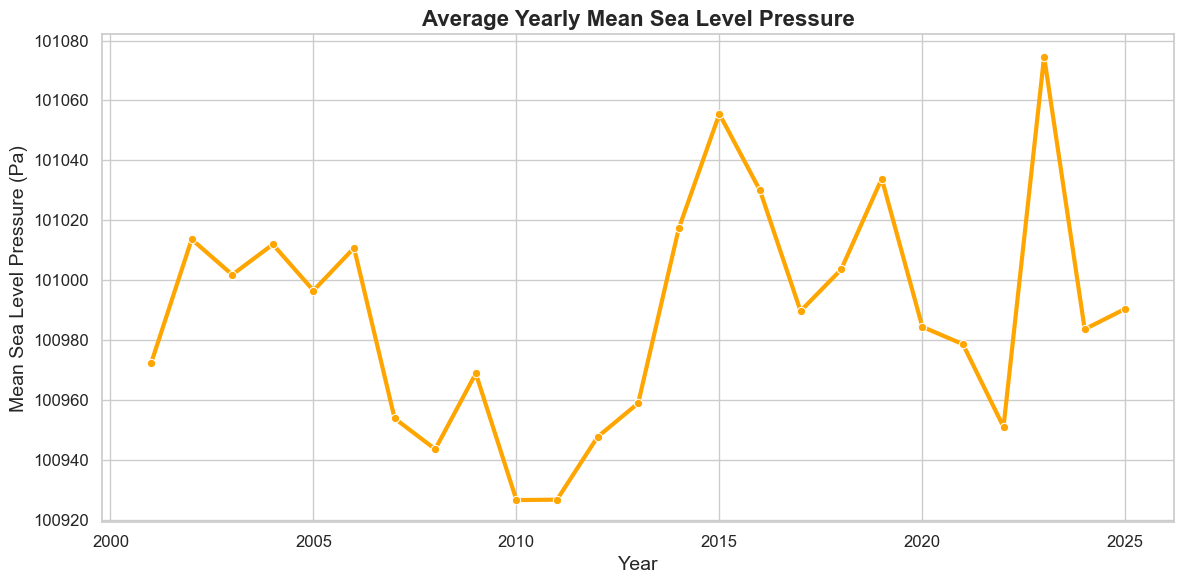

In [32]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df2, x='year', y='msl', marker='o', linewidth=3, color='orange', errorbar=None) 
plt.title('Average Yearly Mean Sea Level Pressure', fontsize=16, weight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Mean Sea Level Pressure (Pa)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()